- Unlike PCA/SVD (which preserve global variance), t-SNE focuses on preserving local structure — meaning points that are close in high-dimensional space remain close in the reduced space.
- It converts distances between points into probabilities of similarity and then minimizes the difference between high-dimensional and low-dimensional distributions.


🔹 What is t-SNE?
t-SNE (t-distributed Stochastic Neighbor Embedding) is a technique that reduces high-dimensional data into 2D or 3D for visualization.
- It focuses on local neighborhoods: points that are close in the original space stay close in the reduced space.
- Unlike PCA/SVD (which maximize variance explained), t-SNE tries to show clusters and groupings more clearly.

🔹 Sample Example
Imagine you have a dataset of handwritten digits (0–9) with 784 features (28×28 pixel values).
- In raw form, it’s impossible to visualize.
- PCA/SVD might reduce it to 50 components, keeping most variance.
- Then t-SNE can take those 50 components and project them into 2D.
Result:
- Digits “0” cluster together, “1” cluster together, etc.
- You can see clear separation between groups, even though the original data had 784 dimensions.

In [10]:
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

import plotly.express as px
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

In [6]:
# load dataset
df = sns.load_dataset('diamonds')
df_sample = df.sample(5000, random_state=42)

# select numeric columns to scale
new_data = df_sample[['carat', 'depth', 'table', 'price', 'x', 'y', 'z']]

# initialize scaler and fit-transform
scaler = StandardScaler()
scaled_array = scaler.fit_transform(new_data)

# convert back to DataFrame and keep column names and index
scaled_data = pd.DataFrame(scaled_array, columns=new_data.columns, index=new_data.index)

# now scaled_data contains standardized features
print(scaled_data.head())

          carat     depth     table     price         x         y         z
1388  -1.152108  0.220606 -0.634537 -0.830435 -1.538221 -1.522055 -1.514911
50052 -0.448995 -1.241286 -0.193451 -0.424403 -0.247431 -0.267411 -0.389979
41645 -0.821232  0.220606 -1.075622 -0.662533 -0.844531 -0.868226 -0.831408
42377 -0.759192 -0.684374 -0.193451 -0.646212 -0.704037 -0.735693 -0.788689
17244  1.556944  0.359834 -1.075622  0.737807  1.508745  1.455517  1.532375


In [22]:
# Apply t-SNE (2D projection)
tsne = TSNE(perplexity=30, random_state=42)
tsne_results = tsne.fit_transform(scaled_data)


In [23]:
# Build DataFrame with results + metadata
tsne_df = pd.DataFrame({
    'TSNE1': tsne_results[:,0],
    'TSNE2': tsne_results[:,1],
    'cut': df['cut'],
    'price': df['price']
})

# Interactive scatter plot
fig = px.scatter(
    tsne_df,
    x='TSNE1',
    y='TSNE2',
    color='cut',
    size='price',
    hover_data=['carat','depth','table','x','y','z'],
    title="Diamonds dataset visualized with t-SNE"
)
fig.show()

ValueError: array length 5000 does not match index length 53940

          carat     depth     table     price         x         y         z
1388  -1.152108  0.220606 -0.634537 -0.830435 -1.538221 -1.522055 -1.514911
50052 -0.448995 -1.241286 -0.193451 -0.424403 -0.247431 -0.267411 -0.389979
41645 -0.821232  0.220606 -1.075622 -0.662533 -0.844531 -0.868226 -0.831408
42377 -0.759192 -0.684374 -0.193451 -0.646212 -0.704037 -0.735693 -0.788689
17244  1.556944  0.359834 -1.075622  0.737807  1.508745  1.455517  1.532375


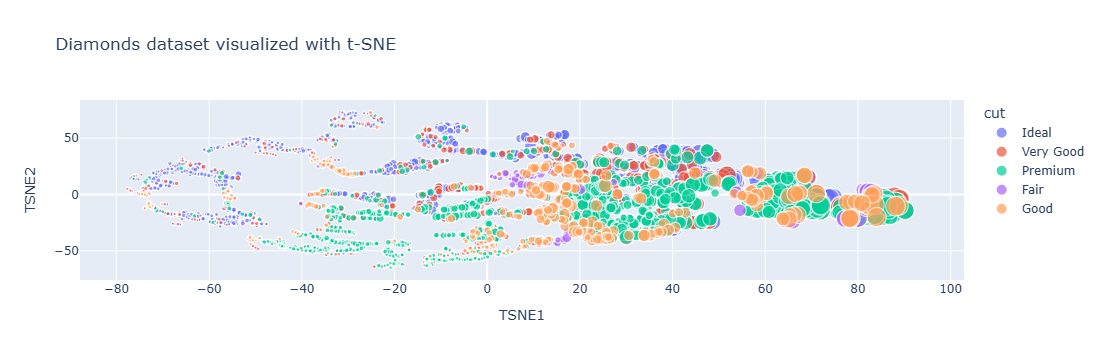

In [21]:
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
import plotly.express as px

# load dataset
df = sns.load_dataset('diamonds')

# sample 5000 rows (keep same subset for metadata)
df_sample = df.sample(5000, random_state=42)

# select numeric columns to scale
new_data = df_sample[['carat', 'depth', 'table', 'price', 'x', 'y', 'z']]

# initialize scaler and fit-transform
scaler = StandardScaler()
scaled_array = scaler.fit_transform(new_data)

# convert back to DataFrame and keep column names and index
scaled_data = pd.DataFrame(scaled_array, columns=new_data.columns, index=new_data.index)

# now scaled_data contains standardized features
print(scaled_data.head())

# Apply t-SNE (2D projection)
tsne = TSNE(n_components=2,perplexity=30, random_state=0)
tsne_results = tsne.fit_transform(scaled_data)

# Build DataFrame with results + metadata from the same sampled rows
tsne_df = pd.DataFrame({
    'TSNE1': tsne_results[:, 0],
    'TSNE2': tsne_results[:, 1],
    'cut': df_sample['cut'].values,
    'price': df_sample['price'].values,
    'carat': df_sample['carat'].values,
    'depth': df_sample['depth'].values,
    'table': df_sample['table'].values,
    'x': df_sample['x'].values,
    'y': df_sample['y'].values,
    'z': df_sample['z'].values
}, index=new_data.index)

# Interactive scatter plot
fig = px.scatter(
    tsne_df,
    x='TSNE1',
    y='TSNE2',
    color='cut',
    size='price',
    hover_data=['carat', 'depth', 'table', 'x', 'y', 'z'],
    title="Diamonds dataset visualized with t-SNE"
)
fig.show()